In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np


In [68]:
import pandas as pd

def load_data(file_path):
    """
    Load data from a CSV file into a pandas DataFrame.

    Parameters:
    file_path (str): The path to the CSV file.

    Returns:
    pd.DataFrame: A DataFrame containing the loaded data.
    """
    try:
        data = pd.read_csv(file_path)
        return data
    except FileNotFoundError:
        print(f"Error: The file at {file_path} was not found.")
        return None
    except pd.errors.EmptyDataError:
        print("Error: The file is empty.")
        return None
    except pd.errors.ParserError:
        print("Error: There was a parsing error while reading the file.")
        return None

In [69]:
file_path = '/Users/raman/Elnino/data/ERA5/climfillused_pacific.csv'

In [70]:
df = pd.read_csv(file_path)
df.head()

,time,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,lsm,land_ocean
0,1980-01-01,-30.0,120.0,-0.157461,0.001843,-24030192.0,NaN,302.30980,100920.375,1.000000,land
1,1980-01-01,-30.0,122.0,-0.160635,0.015271,-24052208.0,NaN,301.18090,100998.125,0.899545,land
2,1980-01-01,-30.0,124.0,-0.098501,0.038526,-24364784.0,NaN,300.44263,101090.500,1.000000,land
3,1980-01-01,-30.0,126.0,-0.121206,0.080945,-24769008.0,NaN,300.43286,101106.625,1.000000,land
4,1980-01-01,-30.0,128.0,-0.126822,0.099744,-24659952.0,NaN,298.79420,101150.000,1.000000,land


In [71]:
df.describe()

,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,lsm
count,1.398627e+06,1.398627e+06,1.398627e+06,1.398627e+06,1.398627e+06,1.277201e+06,1.398627e+06,1.398627e+06,1.398627e+06
mean,0.000000e+00,2.000000e+02,-4.543197e-02,3.006749e-03,-2.274049e+07,2.992733e+02,2.976173e+02,1.013253e+05,8.879291e-02
std,1.788855e+01,4.676182e+01,5.312794e-02,3.972991e-02,2.091728e+06,3.035616e+00,3.343414e+00,3.844733e+02,2.750656e-01
min,-3.000000e+01,1.200000e+02,-1.214612e+00,-8.906822e-01,-2.784126e+07,2.838455e+02,2.738076e+02,1.000191e+05,0.000000e+00
25%,-1.600000e+01,1.600000e+02,-7.506943e-02,-1.642799e-02,-2.437277e+07,2.974614e+02,2.958657e+02,1.010292e+05,0.000000e+00
50%,0.000000e+00,2.000000e+02,-4.533672e-02,2.184868e-03,-2.307474e+07,3.000400e+02,2.987202e+02,1.012439e+05,0.000000e+00
75%,1.600000e+01,2.400000e+02,-1.576519e-02,2.287197e-02,-2.143781e+07,3.016628e+02,3.000410e+02,1.015865e+05,0.000000e+00
max,3.000000e+01,2.800000e+02,8.912992e-01,6.666050e-01,-1.242472e+07,3.053018e+02,3.096585e+02,1.030612e+05,1.000000e+00


In [72]:
for col in df.select_dtypes(include = ['number']).columns:
    print(f"end={col} min={df[col].min()} max={df[col].max()} mean={df[col].mean()} std={df[col].std()} range  = {df[col].max() - df[col].min()}")

end=latitude min=-30.0 max=30.0 mean=0.0 std=17.888550215039103 range  = 60.0
end=longitude min=120.0 max=280.0 mean=200.0 std=46.76182449504973 range  = 160.0
end=avg_iews min=-1.214612 max=0.89129925 mean=-0.04543197392674503 std=0.053127935045884415 range  = 2.10591125
end=avg_inss min=-0.8906822204589844 max=0.666605 mean=0.0030067487523422758 std=0.039729914839088616 range  = 1.5572872204589845
end=ttr min=-27841264.0 max=-12424720.0 mean=-22740485.81632129 std=2091728.2514945546 range  = 15416544.0
end=sst min=283.84546 max=305.30176 mean=299.27325640333476 std=3.035616215417852 range  = 21.4563
end=t2m min=273.80762 max=309.65845 mean=297.61733105418915 std=3.3434144224772484 range  = 35.85083000000003
end=msl min=100019.125 max=103061.25 mean=101325.25105472008 std=384.4733126008165 range  = 3042.125
end=lsm min=0.0 max=1.0 mean=0.08879291299138588 std=0.27506559544748205 range  = 1.0


In [89]:
# Anomaly Computation
BASELINE_START = '1980-01-01'
BASELINE_END   = '2010-12-31'
CLIM_VARS = ['avg_iews', 'avg_inss', 'ttr', 'sst', 't2m', 'msl']

df['time'] = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month

# Round lat/lon to avoid float merge-key mismatches
df['latitude'] = df['latitude'].round(4)
df['longitude'] = df['longitude'].round(4)

baseline = df[(df['time'] >= BASELINE_START) & (df['time'] <= BASELINE_END)]
clim_mean = (
    baseline
    .groupby(['latitude', 'longitude', 'month'])[CLIM_VARS]
    .mean()
    .rename(columns={v: f'{v}_clim' for v in CLIM_VARS})
    .reset_index()
)

df = df.merge(clim_mean, on=['latitude', 'longitude', 'month'], how='left')
for v in CLIM_VARS:
    df[f'{v}_anom'] = df[v] - df[f'{v}_clim']

df.drop(columns=['month'] + [f'{v}_clim' for v in CLIM_VARS], inplace=True)
anom_cols = [f'{v}_anom' for v in CLIM_VARS]

# --- Z-score normalization using TRAIN-SPLIT statistics (1980-2018), not baseline ---
TRAIN_START = '1980-01-01'
TRAIN_END   = '2018-12-31'

norm_cols = anom_cols  # normalize anomalies only; drop CLIM_VARS here unless you specifically need raw z-scores too
train_for_norm = df[(df['time'] >= TRAIN_START) & (df['time'] <= TRAIN_END)]

mu = train_for_norm[norm_cols].mean()
sigma = train_for_norm[norm_cols].std(ddof=0).replace(0, np.nan)

for c in norm_cols:
    df[f'{c}_z'] = (df[c] - mu[c]) / sigma[c]

z_cols = [f'{c}_z' for c in norm_cols]

# Save stats for de-normalizing predictions later
pd.DataFrame({'mean': mu, 'std': sigma}).to_csv('norm_stats_1980_2018.csv')

cols_to_show = ['time', 'latitude', 'longitude'] + CLIM_VARS + anom_cols + z_cols + ['lsm', 'land_ocean']
df[cols_to_show].head(10)

,time,latitude,longitude,avg_iews,avg_inss,ttr,sst,t2m,msl,avg_iews_anom,...,t2m_anom,msl_anom,avg_iews_anom_z,avg_inss_anom_z,ttr_anom_z,sst_anom_z,t2m_anom_z,msl_anom_z,lsm,land_ocean
0,1980-01-01,-30.0,120.0,-0.157461,0.001843,-24030192.0,NaN,302.30980,100920.375,-0.001085,...,1.244315,-109.844516,-0.021803,-2.212314,0.645620,NaN,1.827051,-0.935435,1.000000,land
1,1980-01-01,-30.0,122.0,-0.160635,0.015271,-24052208.0,NaN,301.18090,100998.125,0.011622,...,0.997660,-84.812419,0.486650,-2.949608,0.327738,NaN,1.447919,-0.725136,0.899545,land
2,1980-01-01,-30.0,124.0,-0.098501,0.038526,-24364784.0,NaN,300.44263,101090.500,0.013465,...,1.229212,-66.937581,0.560389,-1.125986,0.048551,NaN,1.803836,-0.574967,1.000000,land
3,1980-01-01,-30.0,126.0,-0.121206,0.080945,-24769008.0,NaN,300.43286,101106.625,0.010070,...,1.170992,-57.699677,0.424571,-0.785730,-0.374418,NaN,1.714346,-0.497358,1.000000,land
4,1980-01-01,-30.0,128.0,-0.126822,0.099744,-24659952.0,NaN,298.79420,101150.000,0.007511,...,0.331915,-41.909355,0.322155,-0.725947,-0.389532,NaN,0.424610,-0.364701,1.000000,land
5,1980-01-01,-30.0,130.0,-0.105825,0.176343,-24730096.0,NaN,298.24927,101148.375,0.000781,...,-0.155806,-37.623387,0.052882,1.626728,-0.582575,NaN,-0.325060,-0.328694,1.000000,land
6,1980-01-01,-30.0,132.0,-0.051870,0.166089,-25190640.0,NaN,298.83520,101100.125,0.009594,...,-0.593882,-52.025968,0.405506,2.638049,-0.679921,NaN,-0.998422,-0.449692,0.998683,land
7,1980-01-01,-30.0,134.0,-0.024282,0.125745,-25403120.0,NaN,299.91138,101031.500,0.018470,...,-1.076987,-71.994194,0.760650,1.939870,-0.591461,NaN,-1.740997,-0.617448,0.999931,land
8,1980-01-01,-30.0,136.0,-0.020498,0.114942,-24812784.0,NaN,299.25122,100986.125,0.022888,...,-2.412047,-76.682903,0.937435,1.263804,-0.175431,NaN,-3.793103,-0.656839,0.994428,land
9,1980-01-01,-30.0,138.0,0.012705,0.169568,-24867824.0,NaN,300.18090,100911.875,0.042155,...,-2.027476,-105.639194,1.708385,3.510246,-0.191637,NaN,-3.201983,-0.900105,0.999131,land


In [80]:
# Compute monthly Nino 3.4 index from SST anomalies
# Region: 5S-5N, 170W-120W (in 0-360 longitude: 190E-240E)

n34 = df[['time', 'latitude', 'longitude', 'sst_anom']].dropna().copy()

# Convert longitude to 0-360 safely
n34['lon360'] = n34['longitude'] % 360

# Nino 3.4 spatial mask
n34_mask = (
    (n34['latitude'] >= -5) & (n34['latitude'] <= 5) &
    (n34['lon360'] >= 190) & (n34['lon360'] <= 240)
)
n34_region = n34.loc[n34_mask].copy()

# Area-weight by latitude to avoid high-lat over-representation
n34_region['w'] = np.cos(np.deg2rad(n34_region['latitude']))

# Weighted monthly average anomaly = Nino 3.4 index
nino34_df = (
    n34_region
    .groupby('time')
    .apply(lambda g: np.average(g['sst_anom'], weights=g['w']))
    .reset_index(name='nino34')
    .sort_values('time')
)

print('Nino 3.4 rows:', len(nino34_df))
nino34_df.head(12)

Nino 3.4 rows: 557


,time,nino34
0,1980-01-01,0.563570
1,1980-02-01,0.368783
2,1980-03-01,0.174144
3,1980-04-01,0.213936
4,1980-05-01,0.072503
5,1980-06-01,0.024939
6,1980-07-01,-0.359613
7,1980-08-01,-0.483062
8,1980-09-01,-0.175311
9,1980-10-01,-0.340846


Nino 3.4 CSV saved to: /Users/raman/Elnino/data/ERA5/nino34_index_monthly.csv


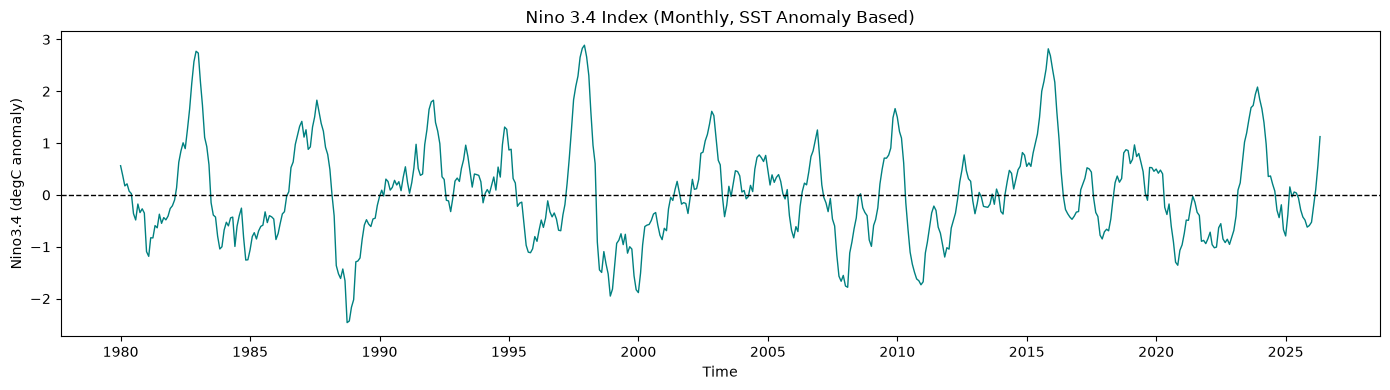

In [81]:
# Save and visualize Nino 3.4 index
nino34_export = '/Users/raman/Elnino/data/ERA5/nino34_index_monthly.csv'
nino34_df.to_csv(nino34_export, index=False)
print(f'Nino 3.4 CSV saved to: {nino34_export}')

plt.figure(figsize=(14, 4))
plt.plot(nino34_df['time'], nino34_df['nino34'], color='teal', linewidth=1)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Nino 3.4 Index (Monthly, SST Anomaly Based)')
plt.xlabel('Time')
plt.ylabel('Nino3.4 (degC anomaly)')
plt.tight_layout()
plt.show()

In [82]:
# Test case: align baseline to NOAA (1991-2020) and validate against downloaded NOAA index
NOAA_BASELINE_START = '1991-01-01'
NOAA_BASELINE_END = '2020-12-31'

# Build Nino3.4 from raw SST with NOAA baseline
n34_raw = df[['time', 'latitude', 'longitude', 'sst']].dropna().copy()
n34_raw['lon360'] = n34_raw['longitude'] % 360

n34_raw = n34_raw[
    (n34_raw['latitude'] >= -5) & (n34_raw['latitude'] <= 5) &
    (n34_raw['lon360'] >= 190) & (n34_raw['lon360'] <= 240)
].copy()

n34_raw['month'] = n34_raw['time'].dt.month

n34_base = n34_raw[
    (n34_raw['time'] >= NOAA_BASELINE_START) &
    (n34_raw['time'] <= NOAA_BASELINE_END)
]

n34_clim = (
    n34_base
    .groupby(['latitude', 'longitude', 'month'])['sst']
    .mean()
    .reset_index(name='sst_clim_noaa_base')
)

n34_raw = n34_raw.merge(n34_clim, on=['latitude', 'longitude', 'month'], how='left')
n34_raw['sst_anom_noaa_base'] = n34_raw['sst'] - n34_raw['sst_clim_noaa_base']
n34_raw['w'] = np.cos(np.deg2rad(n34_raw['latitude']))

nino34_era5_noaa_base = (
    n34_raw
    .groupby('time')
    .apply(lambda g: np.average(g['sst_anom_noaa_base'], weights=g['w']))
    .reset_index(name='nino34_era5_noaa_base')
    .sort_values('time')
)

# Load NOAA time series from local file
noaa = pd.read_csv(
    '/Users/raman/Elnino/nina34.csv',
    skiprows=2,
    names=['time', 'nino34_noaa']
)
noaa['time'] = pd.to_datetime(noaa['time'], errors='coerce')
noaa['nino34_noaa'] = pd.to_numeric(noaa['nino34_noaa'], errors='coerce')
noaa = noaa[noaa['nino34_noaa'] > -9000].dropna().sort_values('time')

# Overlap and validation metrics
compare_df = nino34_era5_noaa_base.merge(noaa, on='time', how='inner')
compare_df['diff'] = compare_df['nino34_era5_noaa_base'] - compare_df['nino34_noaa']

corr = compare_df['nino34_era5_noaa_base'].corr(compare_df['nino34_noaa'])
bias = compare_df['diff'].mean()
rmse = np.sqrt((compare_df['diff'] ** 2).mean())

print('Overlap months:', len(compare_df))
print(f'Correlation: {corr:.3f}')
print(f'Bias (ERA5 - NOAA): {bias:.3f} C')
print(f'RMSE: {rmse:.3f} C')

compare_df.head(12)

Overlap months: 557
Correlation: 0.984
Bias (ERA5 - NOAA): -0.005 C
RMSE: 0.165 C


,time,nino34_era5_noaa_base,nino34_noaa,diff
0,1980-01-01,0.560498,0.54,0.020498
1,1980-02-01,0.320601,0.22,0.100601
2,1980-03-01,0.092693,0.03,0.062693
3,1980-04-01,0.110367,-0.07,0.180367
4,1980-05-01,-0.043093,0.08,-0.123093
5,1980-06-01,-0.098522,0.21,-0.308522
6,1980-07-01,-0.489929,-0.06,-0.429929
7,1980-08-01,-0.542373,-0.38,-0.162373
8,1980-09-01,-0.207664,-0.28,0.072336
9,1980-10-01,-0.417854,-0.26,-0.157854


In [83]:
# Correlation test: ERA5 Nino3.4 (1980-2010 baseline) vs NOAA Nino3.4
noaa_raw = pd.read_csv(
    '/Users/raman/Elnino/nina34.csv',
    skiprows=2,
    names=['time', 'nino34_noaa']
)
noaa_raw['time'] = pd.to_datetime(noaa_raw['time'], errors='coerce')
noaa_raw['nino34_noaa'] = pd.to_numeric(noaa_raw['nino34_noaa'], errors='coerce')
noaa_raw = noaa_raw[noaa_raw['nino34_noaa'] > -9000].dropna().sort_values('time')

compare_1980_2010 = nino34_df.merge(noaa_raw, on='time', how='inner')
compare_1980_2010['diff'] = compare_1980_2010['nino34'] - compare_1980_2010['nino34_noaa']

corr_1980_2010_vs_noaa = compare_1980_2010['nino34'].corr(compare_1980_2010['nino34_noaa'])
bias_1980_2010_vs_noaa = compare_1980_2010['diff'].mean()
rmse_1980_2010_vs_noaa = np.sqrt((compare_1980_2010['diff'] ** 2).mean())

print('Overlap months:', len(compare_1980_2010))
print(f'Correlation (1980-2010 baseline vs NOAA): {corr_1980_2010_vs_noaa:.3f}')
print(f'Bias (ERA5 - NOAA): {bias_1980_2010_vs_noaa:.3f} C')
print(f'RMSE: {rmse_1980_2010_vs_noaa:.3f} C')

Overlap months: 557
Correlation (1980-2010 baseline vs NOAA): 0.983
Bias (ERA5 - NOAA): 0.073 C
RMSE: 0.186 C


In [85]:
# 3-month running mean (ONI-style smoothing) for ERA5 Nino3.4
nino34_3m_df = nino34_df.copy().sort_values('time')
nino34_3m_df['nino34_3m'] = nino34_3m_df['nino34'].rolling(window=3, center=True, min_periods=3).mean()

# Optional: classify ENSO phase from smoothed index
nino34_3m_df['enso_phase'] = 'Neutral'
nino34_3m_df.loc[nino34_3m_df['nino34_3m'] >= 0.5, 'enso_phase'] = 'El Nino'
nino34_3m_df.loc[nino34_3m_df['nino34_3m'] <= -0.5, 'enso_phase'] = 'La Nina'

# Save 3-month running mean index
nino34_3m_export = '/Users/raman/Elnino/data/ERA5/nino34_index_3month_running_mean.csv'
nino34_3m_df.to_csv(nino34_3m_export, index=False)
print(f'3-month Nino3.4 CSV saved to: {nino34_3m_export}')

nino34_3m_df.head(15)

3-month Nino3.4 CSV saved to: /Users/raman/Elnino/data/ERA5/nino34_index_3month_running_mean.csv


,time,nino34,nino34_3m,enso_phase
0,1980-01-01,0.563570,NaN,Neutral
1,1980-02-01,0.368783,0.368832,Neutral
2,1980-03-01,0.174144,0.252288,Neutral
3,1980-04-01,0.213936,0.153528,Neutral
4,1980-05-01,0.072503,0.103793,Neutral
5,1980-06-01,0.024939,-0.087390,Neutral
6,1980-07-01,-0.359613,-0.272579,Neutral
7,1980-08-01,-0.483062,-0.339329,Neutral
8,1980-09-01,-0.175311,-0.333073,Neutral
9,1980-10-01,-0.340846,-0.261289,Neutral


In [87]:
# NOAA ONI-style persistent ENSO classification (5 consecutive overlapping seasons)
def classify_enso_official_oni(
    nino34_3m_df: pd.DataFrame,
    time_col: str = 'time',
    value_col: str = 'nino34_3m',
    threshold: float = 0.5,
    min_persistent_months: int = 5,
) -> pd.DataFrame:
    out = nino34_3m_df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')
    out = out.sort_values(time_col).reset_index(drop=True)

    # Risk check: ONI persistence should not span missing monthly timestamps.
    month_idx = out[time_col].dt.to_period('M').astype('int64')
    month_step = month_idx.diff()
    has_gaps = month_step.dropna().ne(1).any()
    if has_gaps:
        print('WARNING: Monthly gaps detected. Persistence is computed on consecutive rows, so gaps can distort episodes.')

    # NaNs naturally map to False in comparisons and therefore break runs.
    s = out[value_col]
    el_candidate = s.ge(threshold)
    la_candidate = s.le(-threshold)

    def _flag_persistent_runs(candidate_mask: pd.Series, min_len: int) -> pd.Series:
        block_id = candidate_mask.ne(candidate_mask.shift(fill_value=False)).cumsum()
        block_true_len = candidate_mask.groupby(block_id).transform('sum')
        return candidate_mask & (block_true_len >= min_len)

    out['el_nino_official'] = _flag_persistent_runs(el_candidate, min_persistent_months)
    out['la_nina_official'] = _flag_persistent_runs(la_candidate, min_persistent_months)

    out['enso_phase_official'] = np.select(
        [out['el_nino_official'], out['la_nina_official']],
        ['El Nino', 'La Nina'],
        default='Neutral'
    )

    return out


def summarize_episodes(df: pd.DataFrame, flag_col: str, time_col: str = 'time') -> pd.DataFrame:
    m = df[flag_col].fillna(False)
    if not m.any():
        return pd.DataFrame(columns=['start_date', 'end_date', 'months'])

    block_id = m.ne(m.shift(fill_value=False)).cumsum()
    episodes = (
        df.loc[m]
        .groupby(block_id[m], as_index=False)
        .agg(
            start_date=(time_col, 'min'),
            end_date=(time_col, 'max'),
            months=(time_col, 'size')
        )
    )
    return episodes


# Apply official ONI-style classification while keeping existing `enso_phase` unchanged.
nino34_3m_df = classify_enso_official_oni(nino34_3m_df)

# Validation: print El Nino / La Nina episode ranges.
el_episodes = summarize_episodes(nino34_3m_df, 'el_nino_official')
la_episodes = summarize_episodes(nino34_3m_df, 'la_nina_official')

print('\nOfficial El Nino episodes (ONI persistence):')
print(el_episodes.to_string(index=False))

print('\nOfficial La Nina episodes (ONI persistence):')
print(la_episodes.to_string(index=False))

nino34_3m_df[['time', 'nino34_3m', 'enso_phase', 'el_nino_official', 'la_nina_official', 'enso_phase_official']].head(24)


Official El Nino episodes (ONI persistence):
 el_nino_official start_date   end_date  months
                1 1982-04-01 1983-05-01      14
                3 1986-09-01 1988-01-01      17
                5 1991-09-01 1992-06-01      10
                7 1994-09-01 1995-02-01       6
                9 1997-05-01 1998-04-01      12
               11 2002-06-01 2003-02-01       9
               13 2004-08-01 2004-12-01       5
               15 2006-09-01 2007-01-01       5
               17 2009-07-01 2010-04-01      10
               19 2014-10-01 2016-04-01      19
               21 2018-10-01 2019-06-01       9
               23 2023-05-01 2024-05-01      13

Official La Nina episodes (ONI persistence):
 la_nina_official start_date   end_date  months
                1 1980-12-01 1981-07-01       8
                3 1983-09-01 1984-03-01       7
                5 1984-10-01 1985-07-01      10
                7 1988-04-01 1989-10-01      19
                9 1995-08-01 1996-05-01     

,time,nino34_3m,enso_phase,el_nino_official,la_nina_official,enso_phase_official
0,1980-01-01,NaN,Neutral,False,False,Neutral
1,1980-02-01,0.368832,Neutral,False,False,Neutral
2,1980-03-01,0.252288,Neutral,False,False,Neutral
3,1980-04-01,0.153528,Neutral,False,False,Neutral
4,1980-05-01,0.103793,Neutral,False,False,Neutral
5,1980-06-01,-0.087390,Neutral,False,False,Neutral
6,1980-07-01,-0.272579,Neutral,False,False,Neutral
7,1980-08-01,-0.339329,Neutral,False,False,Neutral
8,1980-09-01,-0.333073,Neutral,False,False,Neutral
9,1980-10-01,-0.261289,Neutral,False,False,Neutral


In [88]:
# Export ONI-classified 3-month Nino3.4 dataframe
nino34_oni_export = '/Users/raman/Elnino/data/ERA5/nino34_index_3month_running_mean_official_oni.csv'
nino34_3m_df.to_csv(nino34_oni_export, index=False)
print(f'ONI-classified Nino3.4 CSV saved to: {nino34_oni_export}')

ONI-classified Nino3.4 CSV saved to: /Users/raman/Elnino/data/ERA5/nino34_index_3month_running_mean_official_oni.csv


In [90]:
# Export the combined original+anomaly+zscore dataframe to CSV
export_path = '/Users/raman/Elnino/data/ERA5/era5_with_original_anomaly_zscore.csv'
df[cols_to_show].to_csv(export_path, index=False)
print(f'CSV saved to: {export_path}')

CSV saved to: /Users/raman/Elnino/data/ERA5/era5_with_original_anomaly_zscore.csv
